Saved: /Users/nandan/Desktop/CTCs/IBM/ns2_psucc_comparison.png
Saved: /Users/nandan/Desktop/CTCs/IBM/ns2_psucc_comparison.pdf


/var/folders/dg/bj9b922n29vcxp68247bp7vh0000gn/T/ipykernel_8544/1517935691.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20),


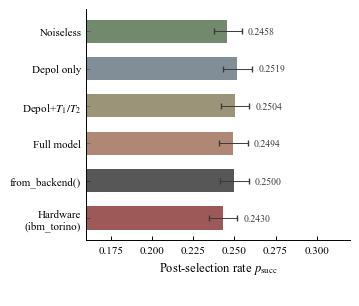

In [2]:
"""
Figure NS2: Noisy-simulator validation — post-selection rate p_succ
Single-column (~3.4 in), Times serif, paper palette.
"""
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Data ----------------
with open("noisy_sim_validation_results.json") as f:
    d = json.load(f)

# Order from top to bottom of the figure (matches the original draft)
rows = [
    ("Noiseless",        d["sim_results"]["NM0_noiseless"]),
    ("Depol only",       d["sim_results"]["NM1_depol"]),
    (r"Depol+$T_1/T_2$", d["sim_results"]["NM2_thermal"]),
    ("Full model",       d["sim_results"]["NM3_full"]),
    ("from_backend()",   d["sim_results"]["NM4_auto"]),
    ("Hardware\n(ibm_torino)", d["hardware"]),
]

labels = [r[0] for r in rows]
p      = np.array([r[1]["p_succ"] for r in rows])
p_lo   = np.array([r[1]["p_lo"]   for r in rows])
p_hi   = np.array([r[1]["p_hi"]   for r in rows])
p_err  = np.vstack([p - p_lo, p_hi - p])

p_hw   = d["hardware"]["p_succ"]      # 0.2430
hw_lo  = d["hardware"]["p_lo"]
hw_hi  = d["hardware"]["p_hi"]

# ---------------- PRL rcParams ----------------
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":    "stix",
    "font.size":           8,
    "axes.labelsize":      9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "legend.fontsize":     7.0,
    "axes.linewidth":      0.7,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           False,
    "ytick.right":         False,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":        "tight",
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# Paper palette (consistent with previous figures)
C_PS    = "#5b7553"   # sage
C_DYN   = "#8c3b3b"   # brick
C_GREY  = "#3a3a3a"
# Three muted intermediates, tonally matched
C_SLATE = "#6b7a85"   # cool slate (depol only)
C_KHAKI = "#8a8160"   # warm khaki (depol+T1/T2)
C_WARM  = "#a0735d"   # soft terra (full model)

# Color per row (top -> bottom)
bar_colors = [C_PS, C_SLATE, C_KHAKI, C_WARM, C_GREY, C_DYN]

# ---------------- Figure ----------------
fig, ax = plt.subplots(figsize=(3.4, 3.0))

y = np.arange(len(labels))[::-1]   # row 0 at top
ax.barh(y, p, height=0.62,
        color=bar_colors, edgecolor="none", alpha=0.85, zorder=2)
ax.errorbar(p, y, xerr=p_err, fmt="none",
            ecolor=C_GREY, elinewidth=0.7, capsize=2.2, zorder=3)

# Value labels just past the error bar
for yi, pi, hi in zip(y, p, p_hi):
    ax.text(hi + 0.004, yi, f"{pi:.4f}",
            ha="left", va="center", fontsize=7, color=C_GREY)

# Ideal reference line
# ax.axvline(0.25, color=C_GREY, lw=0.7, linestyle=(0,(3,2)),
#            label=r"Ideal $p_{\mathrm{succ}} = 0.25$")
# Hardware reference line + CI band
# ax.axvspan(hw_lo, hw_hi, color=C_DYN, alpha=0.10, zorder=0,
#            label="Hardware 95% CI")
# ax.axvline(p_hw, color=C_DYN, lw=0.8, linestyle=(0,(1.5,1.5)),
#            label=f"Hardware $p_{{\\mathrm{{succ}}}} = {p_hw:.4f}$")

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel(r"Post-selection rate $p_{\mathrm{succ}}$")
ax.set_xlim(0.16, 0.32)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20),
          frameon=False, handlelength=1.6, ncol=1,
          borderaxespad=0.2, labelspacing=0.35)

# Save
out_png = "/Users/nandan/Desktop/CTCs/IBM/ns2_psucc_comparison.png"
out_pdf = "/Users/nandan/Desktop/CTCs/IBM/ns2_psucc_comparison.pdf"
plt.savefig(out_png, dpi=600)
plt.savefig(out_pdf)
print("Saved:", out_png)
print("Saved:", out_pdf)